# 🫀 Análise Exploratória de Dados — Heart Disease UCI

**Disciplina:** Ciência de Dados  
**Dataset:** Heart Disease UCI (920 registros, 4 centros clínicos)

---

## Dicionário de Variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `age` | Numérica | Idade em anos |
| `sex` | Categórica | Sexo (Male / Female) |
| `dataset` | Categórica | Centro de coleta (Cleveland, Hungary, Switzerland, VA Long Beach) |
| `cp` | Categórica | Tipo de dor no peito |
| `trestbps` | Numérica | Pressão arterial em repouso (mmHg) |
| `chol` | Numérica | Colesterol sérico (mg/dL) |
| `fbs` | Binária | Glicemia em jejum > 120 mg/dL |
| `restecg` | Categórica | Resultado do ECG em repouso |
| `thalch` | Numérica | Frequência cardíaca máxima atingida |
| `exang` | Binária | Angina induzida por exercício |
| `oldpeak` | Numérica | Depressão do segmento ST induzida por exercício |
| `slope` | Categórica | Inclinação do segmento ST no pico do exercício |
| `ca` | Numérica | Número de vasos coloridos por fluoroscopia (0–3) |
| `thal` | Categórica | Resultado do teste de talassemia |
| `num` | Target | Diagnóstico de doença cardíaca (0 = ausente; 1–4 = presente) |

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import shapiro, skew, kurtosis, normaltest, spearmanr, kruskal, chi2_contingency, pointbiserialr
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
PALETTE_TARGET = sns.color_palette('RdYlGn_r', 5)
PALETTE_SEX    = {'Male': '#4878CF', 'Female': '#D65F5F'}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Visão Geral

In [2]:
df = pd.read_csv('data/heart_disease_uci.csv')

# Separação de colunas
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
target   = 'num'

print(f'Formato: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'\nCentros de coleta:')
print(df['dataset'].value_counts())
print(f'\nDistribuição de sexo:')
print(df['sex'].value_counts())
df.head()

Formato: 920 linhas × 16 colunas

Centros de coleta:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Distribuição de sexo:
sex
Male      726
Female    194
Name: count, dtype: int64


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Análise de Missings e Valores Clinicamente Impossíveis

### 3.1 Missings declarados

In [3]:
missing_summary = pd.DataFrame({
    'missing_n': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(1),
    'zeros_n':   (df == 0).sum(),
    'zeros_%':   ((df == 0).mean() * 100).round(1),
}).sort_values('missing_n', ascending=False)

missing_summary[missing_summary['missing_n'] > 0]

,missing_n,missing_%,zeros_n,zeros_%
ca,611,66.4,181,19.7
thal,486,52.8,0,0.0
slope,309,33.6,0,0.0
fbs,90,9.8,692,75.2
oldpeak,62,6.7,370,40.2
trestbps,59,6.4,1,0.1
exang,55,6.0,528,57.4
thalch,55,6.0,0,0.0
chol,30,3.3,172,18.7
restecg,2,0.2,0,0.0


### 3.2 Padrão de missings por centro de coleta (variável `dataset`)

A variável `dataset` indica a origem dos dados. É fundamental verificar se os missings são aleatórios ou concentrados em centros específicos — o que indicaria falha sistemática de coleta (MNAR — Missing Not At Random).

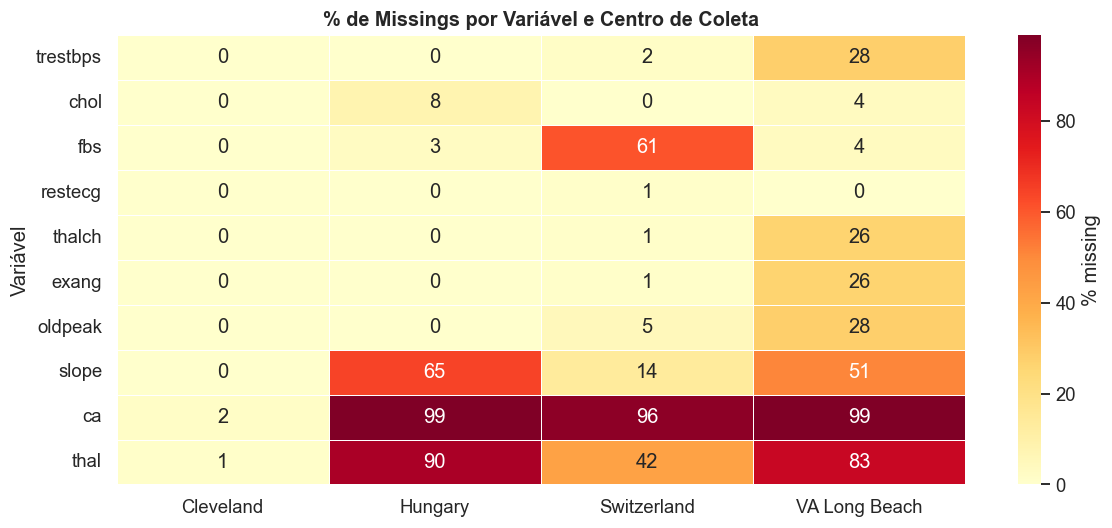

dataset   Cleveland  Hungary  Switzerland  VA Long Beach
trestbps        0.0      0.3          1.6           28.0
chol            0.0      7.8          0.0            3.5
fbs             0.0      2.7         61.0            3.5
restecg         0.0      0.3          0.8            0.0
thalch          0.0      0.3          0.8           26.5
exang           0.0      0.3          0.8           26.5
oldpeak         0.0      0.0          4.9           28.0
slope           0.3     64.5         13.8           51.0
ca              1.6     99.0         95.9           99.0
thal            1.0     90.4         42.3           83.0


In [4]:
cols_with_missing = [c for c in df.columns if df[c].isnull().any()]
miss_by_dataset = df.groupby('dataset')[cols_with_missing].apply(lambda g: g.isnull().mean() * 100).T

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(miss_by_dataset, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% missing'})
ax.set_title('% de Missings por Variável e Centro de Coleta', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()

print(miss_by_dataset.round(1))

> **📌 Insight — Missings MNAR por centro:**  
> - **`ca`**: ausente em ~99% dos registros da Hungria, ~99% da VA Long Beach e ~96% da Suíça. Cleveland é o único centro com dados razoáveis. Isso sugere que o exame de fluoroscopia simplesmente não foi realizado nesses centros — **não é aleatório**.  
> - **`thal`**: padrão similar — ~90% missing na Hungria, ~83% na VA Long Beach, ~42% na Suíça.  
> - **`slope`**: ~65% missing na Hungria e ~51% na VA Long Beach.  
> - **`trestbps` / `thalch` / `exang`**: concentrados na VA Long Beach (~28%).  
> - **Conclusão metodológica:** `ca`, `thal` e `slope` são variáveis com **MNAR estrutural** por centro. Imputação estatística dessas variáveis pode introduzir viés severo. Para modelagem, recomenda-se ou (a) restringir a análise ao subconjunto Cleveland, ou (b) tratar esses campos como ausentes de forma explícita (indicador binário de presença).

### 3.3 Missings disfarçados — zeros clinicamente impossíveis

In [5]:
# Colesterol = 0: clinicamente impossível em indivíduo vivo
chol_zeros_by_ds = df.groupby('dataset')['chol'].apply(lambda x: (x == 0).sum())
print('Zeros em chol por centro:')
print(chol_zeros_by_ds)

# trestbps = 0: impossível (pressão arterial)
print('\nZeros em trestbps por centro:')
print(df.groupby('dataset')['trestbps'].apply(lambda x: (x == 0).sum()))

# Substituir zeros clinicamente impossíveis por NaN
df.loc[df['chol'] == 0, 'chol']         = np.nan
df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan

print('\n✅ Zeros de chol e trestbps convertidos para NaN.')
print(f'   chol missing total:    {df["chol"].isnull().sum()}')
print(f'   trestbps missing total: {df["trestbps"].isnull().sum()}')

Zeros em chol por centro:
dataset
Cleveland          0
Hungary            0
Switzerland      123
VA Long Beach     49
Name: chol, dtype: int64

Zeros em trestbps por centro:
dataset
Cleveland        0
Hungary          0
Switzerland      0
VA Long Beach    1
Name: trestbps, dtype: int64

✅ Zeros de chol e trestbps convertidos para NaN.
   chol missing total:    202
   trestbps missing total: 60


> **📌 Insight — Missings disfarçados:**  
> - **Suíça**: 100% dos registros (`chol` = 0 em todos os 123 casos). O centro não coletou colesterol — é missing estrutural, não medição real.  
> - **VA Long Beach**: ~25% com `chol` = 0, indicando mesma falha de protocolo.  
> - Após a correção, `chol` passa a ter 202 missings (22% do dataset), tornando imputação ainda mais relevante.  
> - Valores de colesterol fisiologicamente muito baixos (< 100 mg/dL) ou muito altos (> 400 mg/dL) também merecem atenção como possíveis outliers clínicos.

## 4. Estratégia de Imputação

Dada a natureza dos missings, adotamos uma estratégia diferenciada:

| Variável | % Missing | Tipo | Estratégia |
|---|---|---|---|
| `ca` | 66% | MNAR estrutural | Indicador binário de presença |
| `thal` | 53% | MNAR estrutural | Indicador binário de presença |
| `slope` | 34% | MNAR estrutural | Indicador binário de presença |
| `chol` | 22% | MNAR por centro | KNN stratificado por `dataset` |
| `oldpeak` | 7% | Provavelmente MAR | KNN imputação |
| `trestbps` | 7% | Provavelmente MAR | KNN imputação |
| `thalch` | 6% | Provavelmente MAR | KNN imputação |
| `fbs`, `exang` | 6–10% | Provavelmente MAR | Moda por grupo target |
| `restecg` | < 1% | Esporádico | Moda global |

In [6]:
df_imp = df.copy()

# --- Indicadores de presença para variáveis MNAR estruturais ---
for col in ['ca', 'thal', 'slope']:
    df_imp[f'{col}_obs'] = df_imp[col].notna().astype(int)

# --- Imputação de variáveis categóricas por moda ---
for col in ['fbs', 'exang', 'restecg']:
    moda = df_imp[col].mode()[0]
    df_imp[col] = df_imp[col].fillna(moda)

# --- Imputação KNN para numéricas (exceto MNAR) ---
# Codificação temporária para KNN
df_knn = df_imp[['age', 'sex', 'dataset', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']].copy()
df_knn['sex_enc']     = LabelEncoder().fit_transform(df_knn['sex'].astype(str))
df_knn['dataset_enc'] = LabelEncoder().fit_transform(df_knn['dataset'].astype(str))

knn_features = ['age', 'sex_enc', 'dataset_enc', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
imputer = KNNImputer(n_neighbors=5)
knn_result = imputer.fit_transform(df_knn[knn_features])
knn_df = pd.DataFrame(knn_result, columns=knn_features)

for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df_imp[col] = knn_df[col].values

# --- Imputação moda para slope e thal (quando necessário usar os valores) ---
df_imp['slope'] = df_imp['slope'].fillna('unknown')
df_imp['thal']  = df_imp['thal'].fillna('unknown')
df_imp['ca']    = df_imp['ca'].fillna(df_imp['ca'].median())

print('✅ Imputação concluída.')
print(f'Missing restantes: {df_imp.isnull().sum().sum()}')

# Criar target binário para análises de associação
df_imp['doenca'] = (df_imp['num'] > 0).astype(int)

print('\nDistribuição do target binário:')
print(df_imp['doenca'].value_counts())

✅ Imputação concluída.
Missing restantes: 0

Distribuição do target binário:
doenca
1    509
0    411
Name: count, dtype: int64


> **📌 Insight — Imputação:**  
> A imputação KNN utiliza as 5 observações mais próximas no espaço multivariado para estimar o valor ausente. É preferível à média/mediana pois preserva relações entre variáveis. Contudo, para `chol` da Suíça (100% missing), os valores imputados são totalmente sintéticos — recomenda-se sensibilidade ao usar esse grupo em análises subsequentes.  
> Os indicadores binários (`ca_obs`, `thal_obs`, `slope_obs`) serão variáveis potencialmente informativas para modelos preditivos.

## 5. Análise Univariada

### 5.1 Distribuições numéricas com teste de normalidade

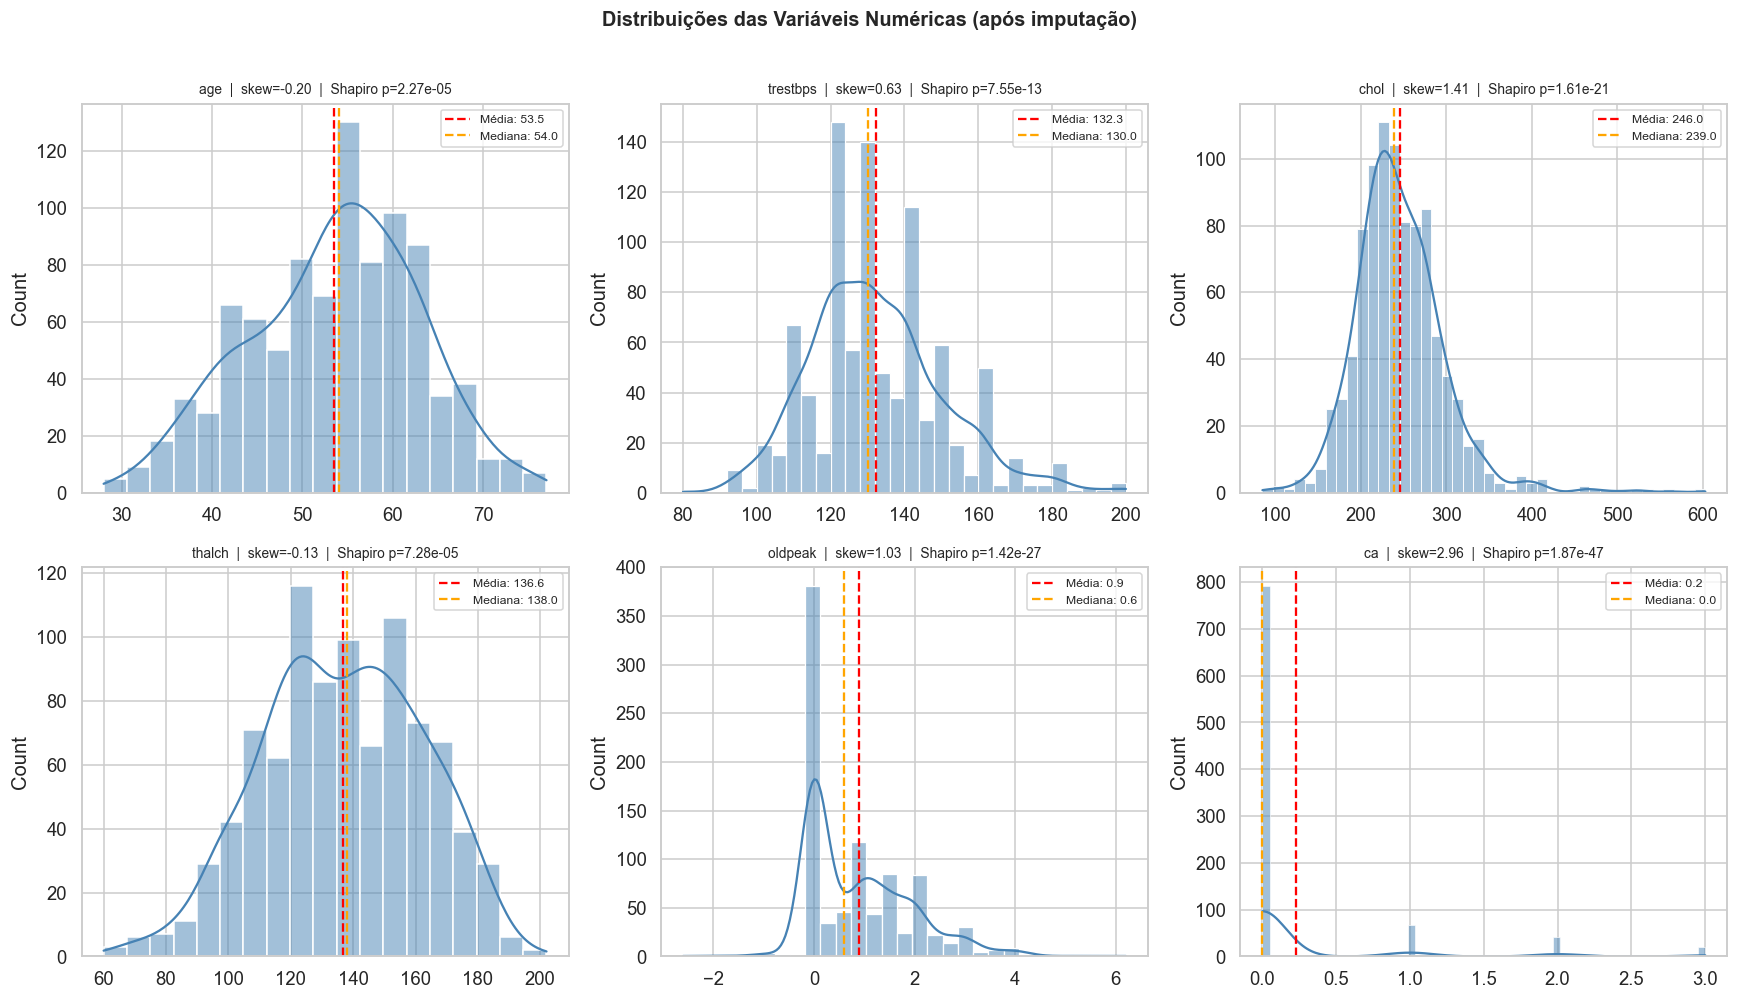

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_imp[col].dropna()
    ax = axes[i]
    sns.histplot(data, kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Média: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {data.median():.1f}')
    _, p_sw = shapiro(data.sample(min(5000, len(data)), random_state=42))
    sk = skew(data)
    ax.set_title(f'{col}  |  skew={sk:.2f}  |  Shapiro p={p_sw:.2e}', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.suptitle('Distribuições das Variáveis Numéricas (após imputação)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
normalidade = []
for col in num_cols:
    data = df_imp[col].dropna()
    samp = data.sample(min(5000, len(data)), random_state=42)
    _, p_sw   = shapiro(samp)
    _, p_dag  = normaltest(data)
    normalidade.append({
        'Variável':       col,
        'Média':          round(data.mean(), 2),
        'Mediana':        round(data.median(), 2),
        'DP':             round(data.std(), 2),
        'CV (%)':         round(data.std() / data.mean() * 100, 1),
        'Assimetria':     round(skew(data), 3),
        'Curtose':        round(kurtosis(data), 3),
        'Shapiro-p':      round(p_sw, 4),
        "D'Agostino-p":   round(p_dag, 4),
        'Normal?':        '✅' if (p_sw > 0.05 and p_dag > 0.05) else '❌'
    })

pd.DataFrame(normalidade).set_index('Variável')

,Média,Mediana,DP,CV (%),Assimetria,Curtose,Shapiro-p,D'Agostino-p,Normal?
Variável,,,,,,,,,
age,53.51,54.0,9.42,17.6,-0.196,-0.387,0.0000,0.0008,❌
trestbps,132.30,130.0,18.10,13.7,0.631,0.737,0.0000,0.0000,❌
chol,245.95,239.0,53.05,21.6,1.415,6.050,0.0000,0.0000,❌
thalch,136.62,138.0,25.58,18.7,-0.131,-0.490,0.0001,0.0001,❌
oldpeak,0.89,0.6,1.06,119.2,1.028,1.256,0.0000,0.0000,❌
ca,0.23,0.0,0.63,276.9,2.960,8.232,0.0000,0.0000,❌


> **📌 Insight — Normalidade:**  
> Nenhuma variável numérica segue distribuição normal (todos os testes rejeitam H₀, p < 0.05). Isso implica que:
> - Estatísticas de associação devem ser **não-paramétricas** (Spearman, Kruskal-Wallis).
> - `oldpeak` tem forte assimetria positiva e curtose elevada — candidata a transformação log.  
> - `chol` e `trestbps` apresentam distribuições razoavelmente simétricas com outliers à direita.  
> - `ca` é discreta (0–3) e deve ser tratada como ordinal ou categórica em alguns contextos.

### 5.2 Distribuições categóricas

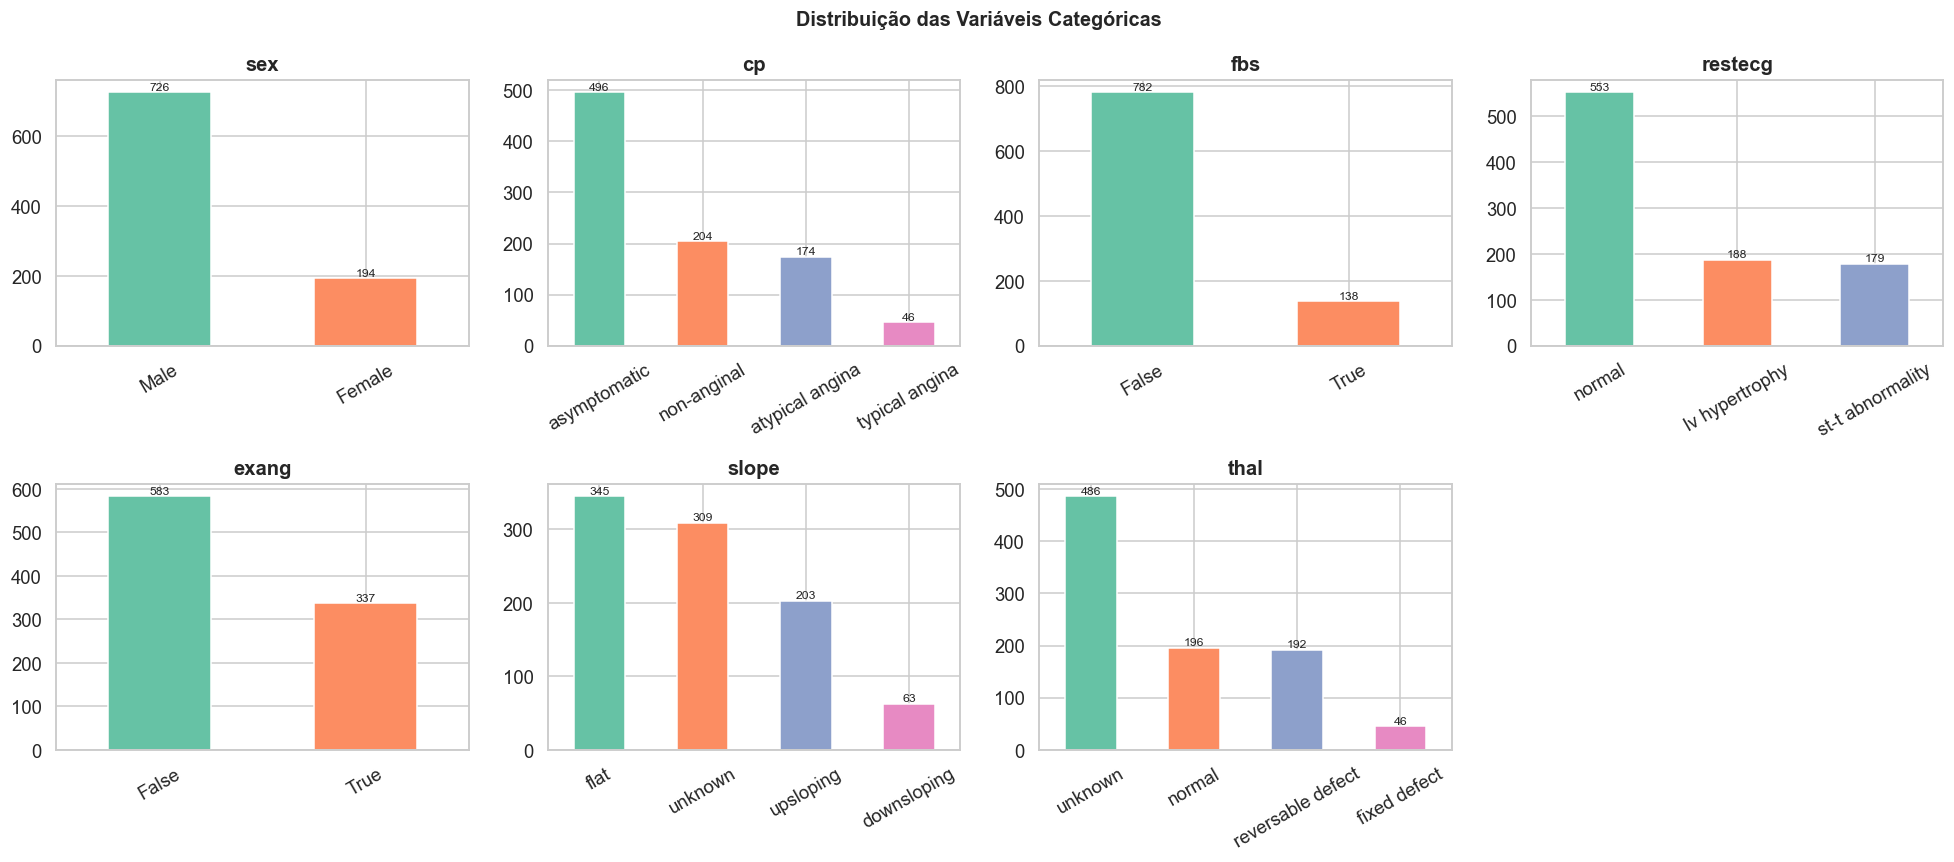

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df_imp[col].value_counts(dropna=False)
    ax = axes[i]
    vc.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Distribuição do Target e criação do target binário

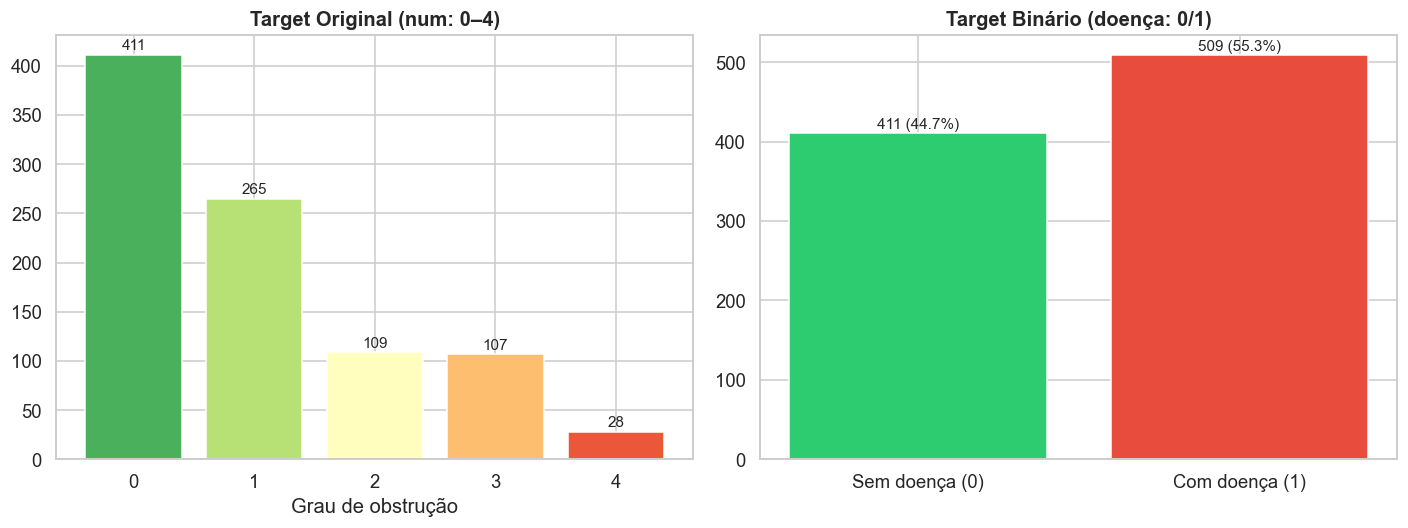

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Target original (0–4)
vc = df_imp['num'].value_counts().sort_index()
bars = axes[0].bar(vc.index.astype(str), vc.values, color=PALETTE_TARGET, edgecolor='white')
axes[0].set_title('Target Original (num: 0–4)', fontweight='bold')
axes[0].set_xlabel('Grau de obstrução')
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5, str(v), ha='center', fontsize=10)

# Target binário
vc2 = df_imp['doenca'].value_counts().sort_index()
bars2 = axes[1].bar(['Sem doença (0)', 'Com doença (1)'], vc2.values,
                    color=['#2ECC71', '#E74C3C'], edgecolor='white')
axes[1].set_title('Target Binário (doença: 0/1)', fontweight='bold')
for b, v in zip(bars2, vc2.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 f'{v} ({v/len(df_imp)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

> **📌 Insight — Target:**  
> O target original tem 5 classes (0–4), mas as classes 3 e 4 são escassas (107 e 28 casos). Para classificação binária (doença presente/ausente), o dataset está relativamente balanceado: 44,7% com doença vs 55,3% sem. Para classificação multiclasse, técnicas de balanceamento (SMOTE, undersampling) podem ser necessárias.

## 6. Análise Estratificada por Sexo

O dataset apresenta forte desbalanceamento: 726 homens (78,9%) vs 194 mulheres (21,1%). Isso exige cautela na interpretação de resultados globais.

=== Prevalência de Doença por Sexo ===
        Com doença  Total  Prevalência (%)
sex                                       
Female          50    194             25.8
Male           459    726             63.2


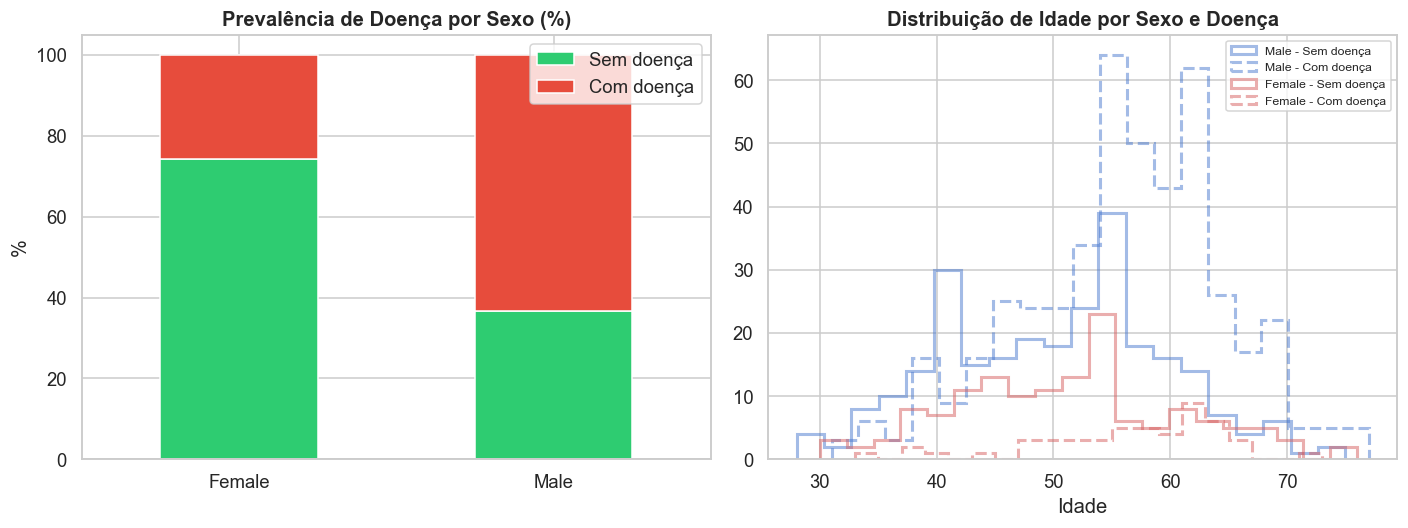

In [11]:
print('=== Prevalência de Doença por Sexo ===')
sex_disease = df_imp.groupby('sex')['doenca'].agg(['sum', 'count', 'mean'])
sex_disease.columns = ['Com doença', 'Total', 'Prevalência']
sex_disease['Prevalência (%)'] = (sex_disease['Prevalência'] * 100).round(1)
print(sex_disease[['Com doença', 'Total', 'Prevalência (%)']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Prevalência por sexo
prev = df_imp.groupby(['sex', 'doenca']).size().unstack(fill_value=0)
prev_pct = prev.div(prev.sum(axis=1), axis=0) * 100
prev_pct.plot(kind='bar', stacked=True, ax=axes[0],
              color=['#2ECC71', '#E74C3C'], edgecolor='white')
axes[0].set_title('Prevalência de Doença por Sexo (%)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Sem doença', 'Com doença'])
axes[0].set_ylabel('%')

# Distribuição de idade por sexo e doença
for sex, color in PALETTE_SEX.items():
    sub = df_imp[df_imp['sex'] == sex]
    axes[1].hist(sub[sub['doenca'] == 0]['age'], bins=20, alpha=0.5,
                 label=f'{sex} - Sem doença', color=color, histtype='step', linewidth=2)
    axes[1].hist(sub[sub['doenca'] == 1]['age'], bins=20, alpha=0.5,
                 label=f'{sex} - Com doença', color=color, linestyle='--',
                 histtype='step', linewidth=2)
axes[1].set_title('Distribuição de Idade por Sexo e Doença', fontweight='bold')
axes[1].set_xlabel('Idade')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

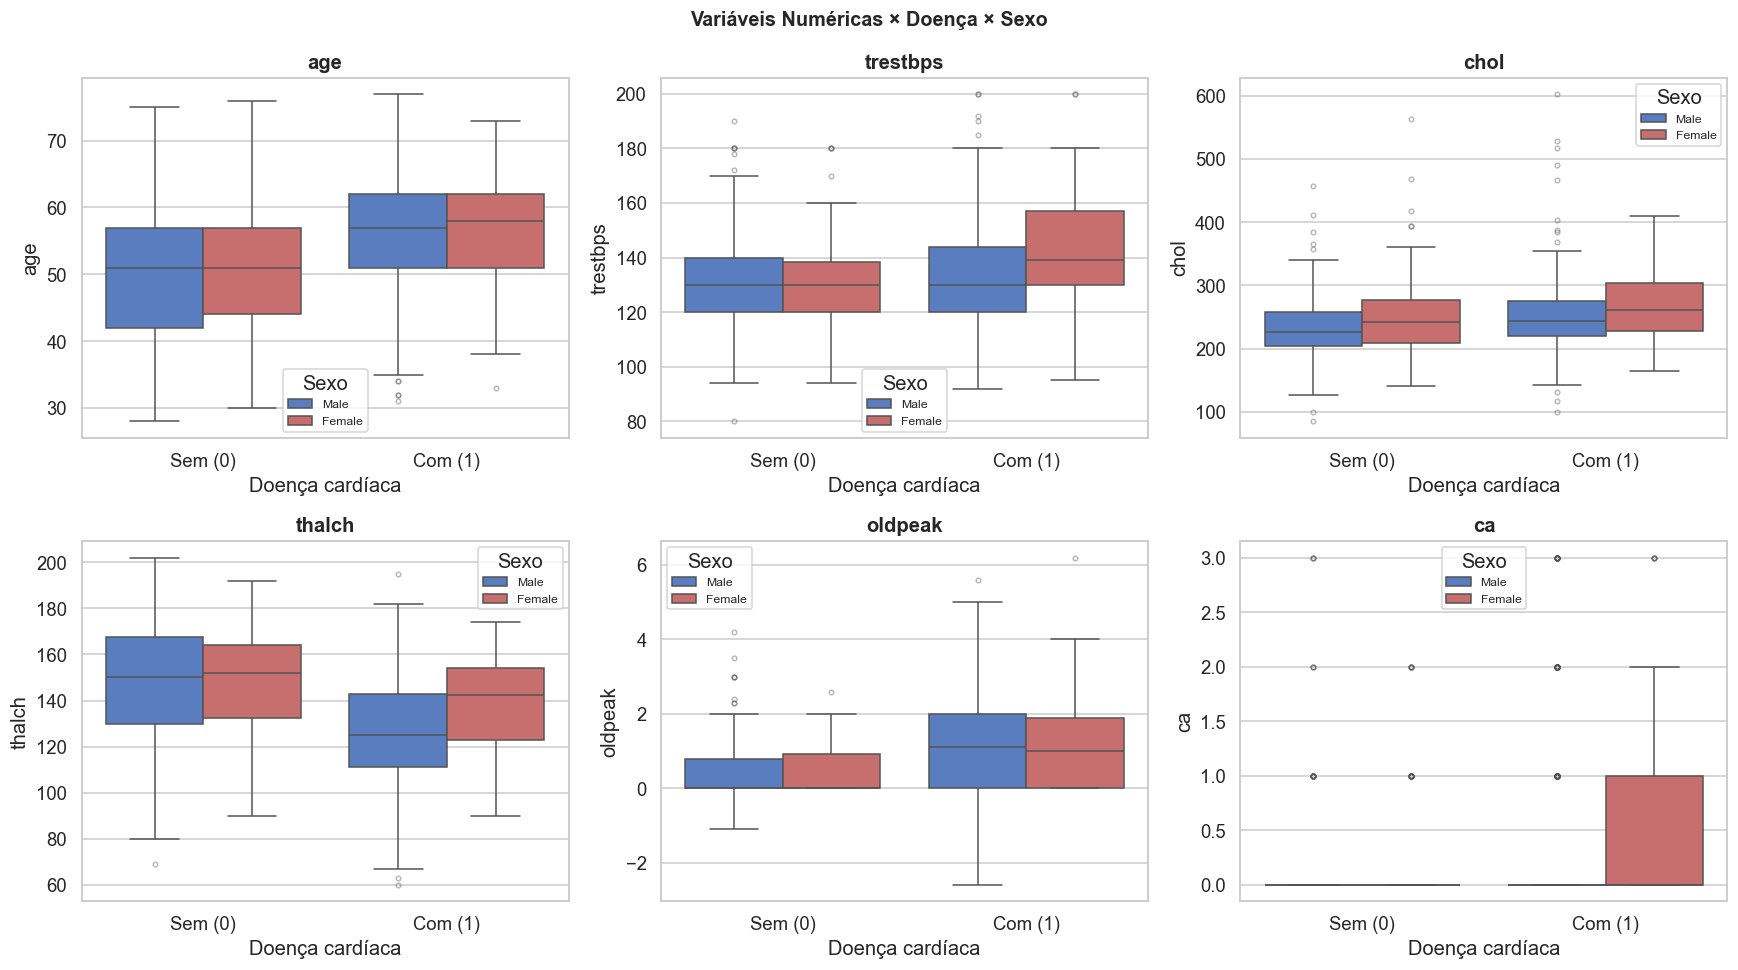

In [12]:
# Boxplots numéricas por sexo e doença
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df_imp, x='doenca', y=col, hue='sex',
                palette=PALETTE_SEX, ax=ax, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Doença cardíaca')
    ax.set_xticklabels(['Sem (0)', 'Com (1)'])
    ax.legend(title='Sexo', fontsize=8)

plt.suptitle('Variáveis Numéricas × Doença × Sexo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Tabela comparativa de médias por sexo e doença
stats_sex = df_imp.groupby(['sex', 'doenca'])[num_cols].mean().round(2)
print('Médias das variáveis numéricas por Sexo × Doença:')
stats_sex

Médias das variáveis numéricas por Sexo × Doença:


age  trestbps    chol  thalch  oldpeak    ca
sex    doenca                                                
Female 0       51.19    128.48  249.89  149.01     0.44  0.15
       1       56.18    142.00  270.19  137.82     1.34  0.62
Male   0       50.20    130.75  233.37  147.00     0.44  0.09
       1       55.87    133.34  249.39  126.57     1.24  0.29

> **📌 Insights — Estratificação por Sexo:**  
> - **Prevalência:** Homens apresentam prevalência de doença cardíaca significativamente maior (~57%) do que mulheres (~26%). Esse achado é consistente com a literatura médica.  
> - **Idade:** Mulheres com doença cardíaca tendem a ser mais velhas que homens com doença — fenômeno associado ao papel protetor do estrogênio até a menopausa.  
> - **`thalch` (frequência cardíaca máxima):** Queda mais acentuada em homens com doença vs sem doença. Em mulheres, o padrão é similar mas com diferenças absolutas menores.  
> - **`oldpeak`:** Elevação consistente com doença em ambos os sexos, mas com maior variabilidade em mulheres.  
> - **Implicação para modelagem:** Um modelo global pode estar enviesado em favor do padrão masculino (dominante). Modelos separados por sexo ou inclusão de interações `sexo × features` podem melhorar performance, especialmente para mulheres.

### 6.2 Variáveis categóricas estratificadas por sexo

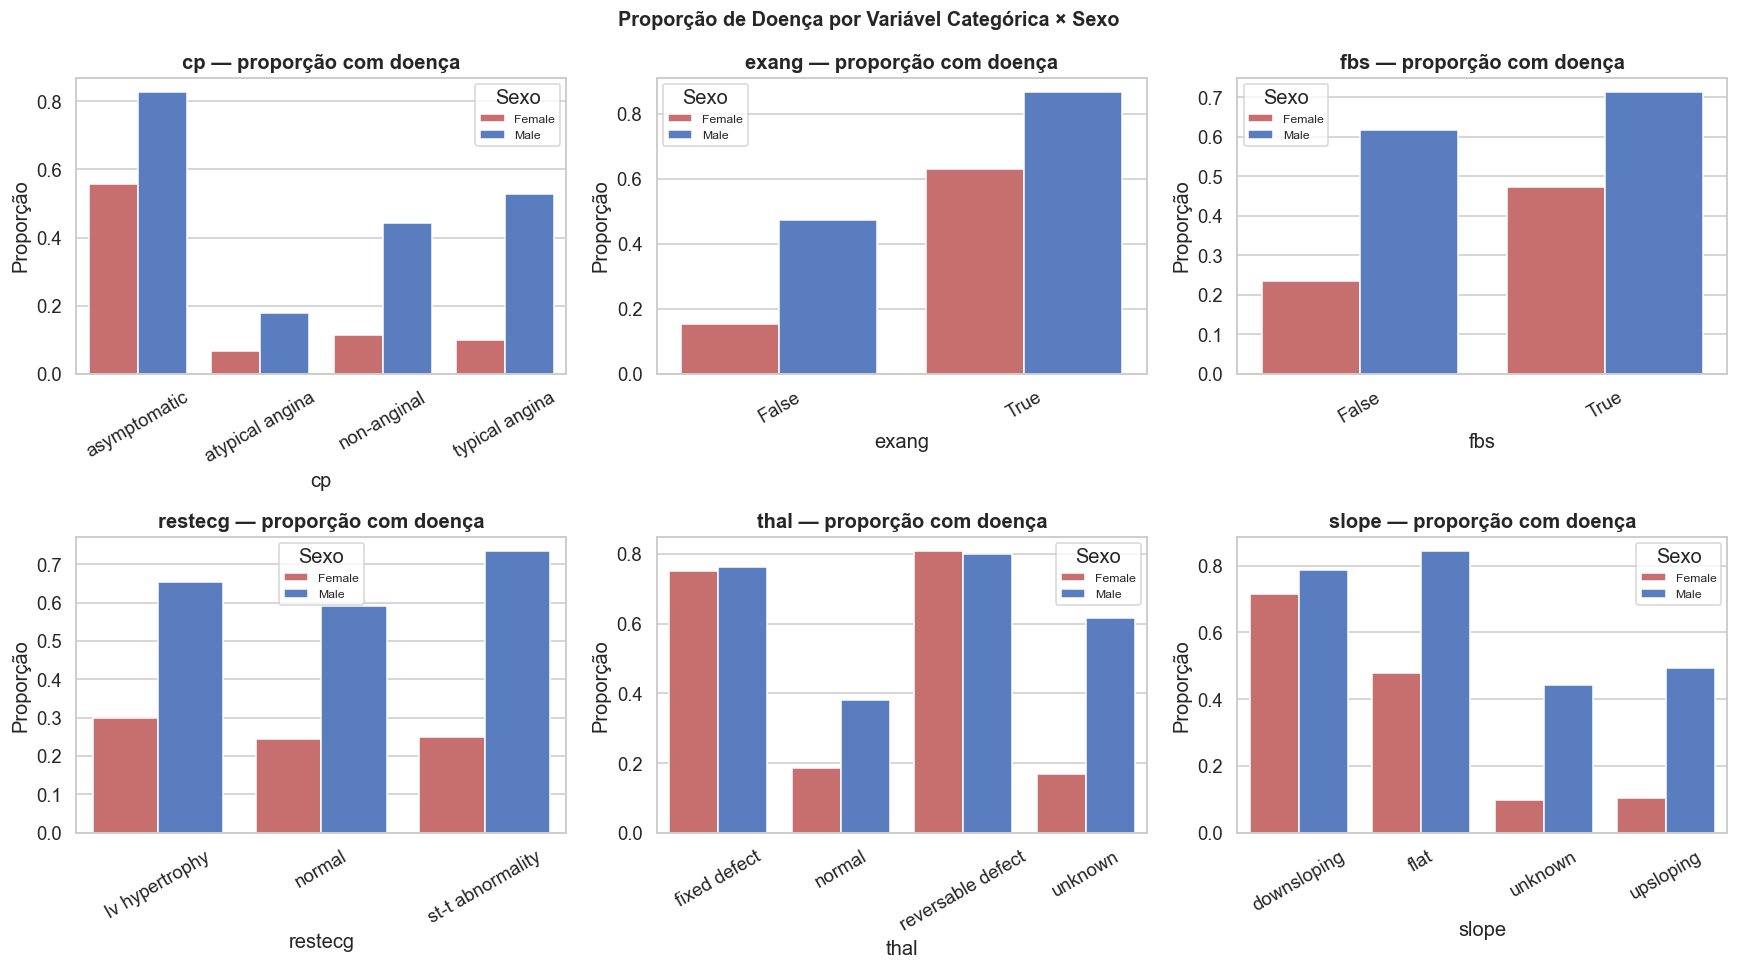

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_plot = ['cp', 'exang', 'fbs', 'restecg', 'thal', 'slope']
for i, col in enumerate(cat_plot):
    ax = axes[i]
    prop = (df_imp.groupby(['sex', col])['doenca']
            .mean().rename('prop_doenca').reset_index())
    sns.barplot(data=prop, x=col, y='prop_doenca', hue='sex',
                palette=PALETTE_SEX, ax=ax)
    ax.set_title(f'{col} — proporção com doença', fontweight='bold')
    ax.set_ylabel('Proporção')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sexo', fontsize=8)

plt.suptitle('Proporção de Doença por Variável Categórica × Sexo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Análise Bivariada — Associação com o Target

### 7.1 Correlação de Spearman e Kruskal-Wallis (variáveis numéricas × target ordinal)

In [15]:
assoc_num = []
for col in num_cols:
    data = df_imp[[col, 'num']].dropna()
    corr_sp, p_sp = spearmanr(data[col], data['num'])
    grupos = [df_imp[df_imp['num'] == i][col].dropna() for i in sorted(df_imp['num'].unique())]
    stat_kw, p_kw = kruskal(*grupos)
    # Point-biserial com target binário
    corr_pb, p_pb = pointbiserialr(df_imp['doenca'], df_imp[col].fillna(df_imp[col].median()))
    assoc_num.append({
        'Variável':        col,
        'Spearman r':      round(corr_sp, 3),
        'Spearman p':      f'{p_sp:.2e}',
        'Kruskal p':       f'{p_kw:.2e}',
        'Point-Biserial':  round(corr_pb, 3),
        'Significativo?':  '✅' if p_sp < 0.05 else '❌'
    })

assoc_df = pd.DataFrame(assoc_num).set_index('Variável')
assoc_df.sort_values('Spearman r', key=abs, ascending=False)

,Spearman r,Spearman p,Kruskal p,Point-Biserial,Significativo?
Variável,,,,,
oldpeak,0.430,1.27e-42,2.77e-36,0.380,✅
thalch,-0.393,2.10e-35,1.58e-31,-0.389,✅
age,0.347,1.87e-27,3.73e-24,0.283,✅
ca,0.222,9.40e-12,2.16e-11,0.165,✅
chol,0.145,1.07e-05,1.93e-04,0.115,✅
trestbps,0.135,3.84e-05,1.32e-03,0.116,✅


> **📌 Insight — Associação numérica × target:**  
> - **`thalch`** (frequência cardíaca máxima) tem a correlação negativa mais forte com o target — pacientes com doença apresentam frequência cardíaca máxima significativamente menor.  
> - **`oldpeak`** (depressão ST) e **`ca`** (vasos coloridos) mostram correlação positiva relevante.  
> - **`age`** tem correlação moderada positiva — pacientes mais velhos têm maior probabilidade de doença.  
> - **`chol`** e **`trestbps`** apresentam correlações fracas, o que é contra-intuitivo clinicamente. Isso pode refletir o impacto dos missings estruturais e da imputação.

### 7.2 Pós-teste de Dunn (comparação par-a-par entre grupos do target)

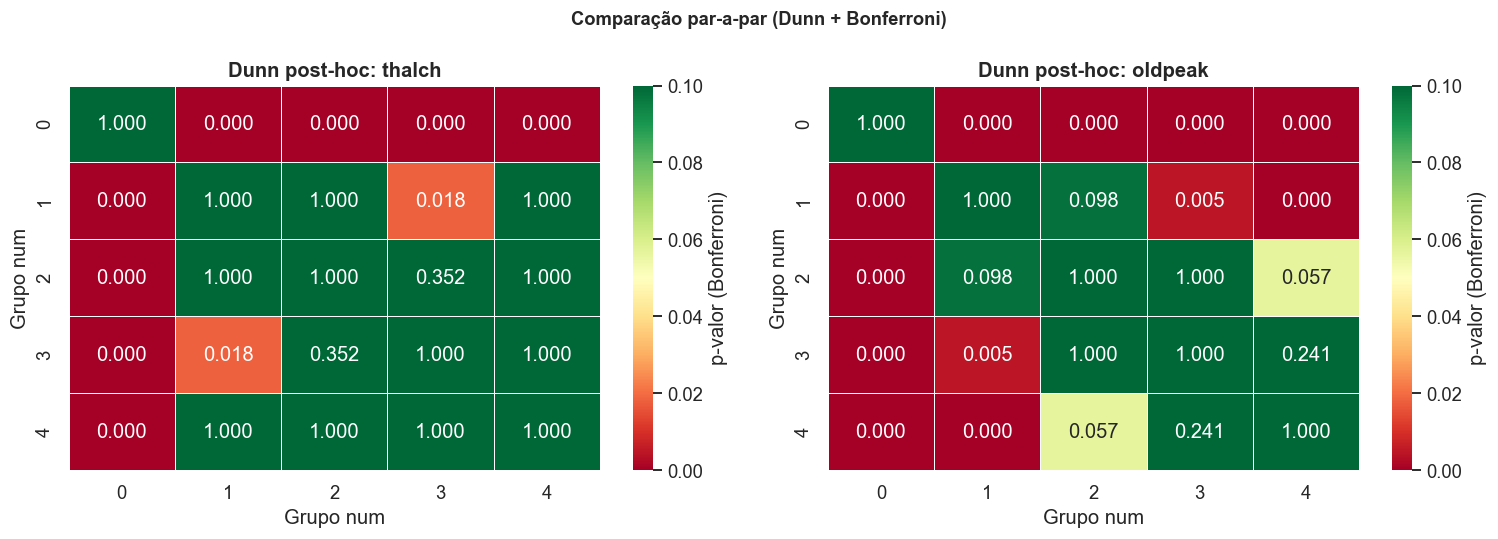

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['thalch', 'oldpeak']):
    dunn = sp.posthoc_dunn(df_imp, val_col=col, group_col='num', p_adjust='bonferroni')
    mask = np.triu(np.ones_like(dunn, dtype=bool), k=1)
    sig_mask = dunn < 0.05
    sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[i],
                vmin=0, vmax=0.1, linewidths=0.5,
                cbar_kws={'label': 'p-valor (Bonferroni)'})
    axes[i].set_title(f'Dunn post-hoc: {col}', fontweight='bold')
    axes[i].set_xlabel('Grupo num')
    axes[i].set_ylabel('Grupo num')

plt.suptitle('Comparação par-a-par (Dunn + Bonferroni)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Qui-quadrado — variáveis categóricas × target binário

In [17]:
chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df_imp[col], df_imp['doenca'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Variável':   col,
        'Chi² stat':  round(chi2, 2),
        'p-valor':    f'{p:.2e}',
        'V de Cramér': round(cramer_v, 3),
        'Associação': 'Forte' if cramer_v > 0.3 else ('Moderada' if cramer_v > 0.15 else 'Fraca'),
        'Significativo?': '✅' if p < 0.05 else '❌'
    })

chi2_df = pd.DataFrame(chi2_results).set_index('Variável')
chi2_df.sort_values('V de Cramér', ascending=False)

,Chi² stat,p-valor,V de Cramér,Associação,Significativo?
Variável,,,,,
cp,268.35,7.04e-58,0.540,Forte,✅
exang,171.17,4.11e-39,0.431,Forte,✅
slope,142.05,1.37e-30,0.393,Forte,✅
thal,109.03,1.78e-23,0.344,Forte,✅
sex,85.36,2.49e-20,0.305,Forte,✅
restecg,11.43,3.30e-03,0.111,Fraca,✅
fbs,10.14,1.45e-03,0.105,Fraca,✅


> **📌 Insight — Associação categórica × target:**  
> - **`cp` (tipo de dor torácica)** e **`thal` (talassemia)** apresentam os maiores V de Cramér — são as variáveis categóricas mais preditivas.  
> - **`exang` (angina por exercício)** também mostra associação forte.  
> - **`fbs` (glicemia em jejum)** tem a menor associação — consistente com a literatura: glicemia em jejum isolada é um preditor fraco de doença coronariana aguda.  
> - Todas as variáveis categóricas são estatisticamente significativas (p < 0.05).

### 7.4 Matriz de correlação — variáveis numéricas

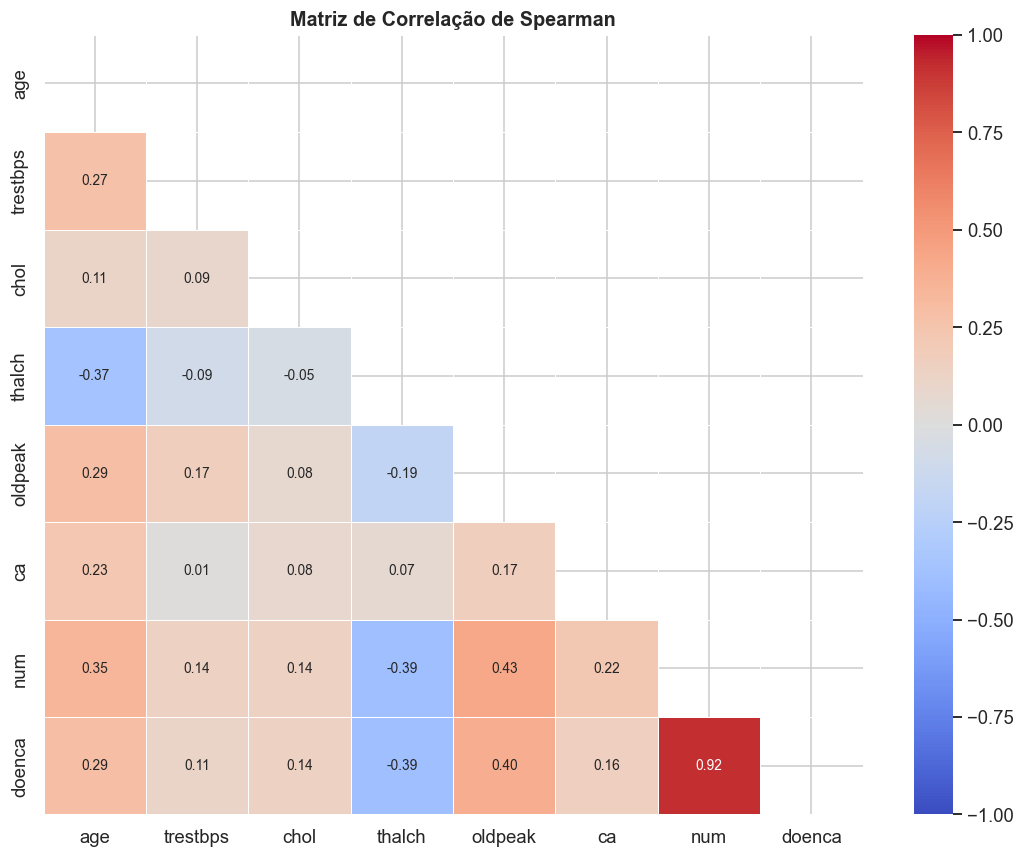

In [18]:
corr_mat = df_imp[num_cols + ['num', 'doenca']].corr(method='spearman')

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação de Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Boxplots — variáveis numéricas por grau de doença (num 0–4)

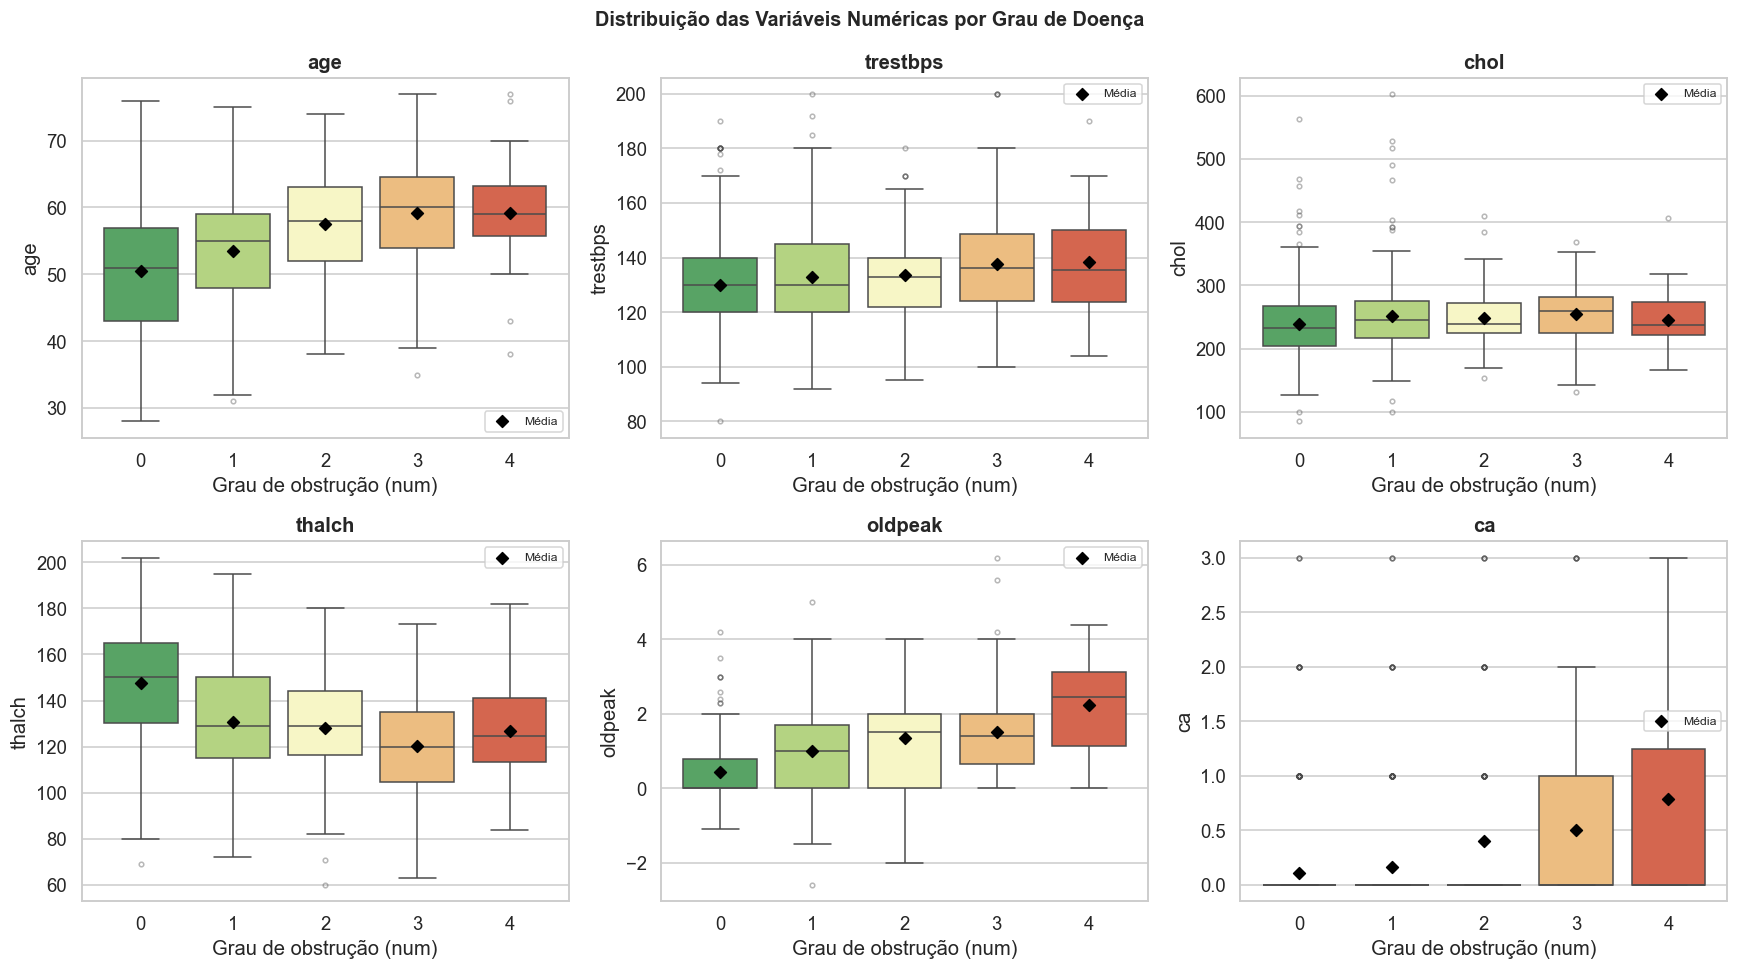

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df_imp, x='num', y=col, palette=PALETTE_TARGET, ax=ax,
                showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.4))
    # Adicionar média como marcador
    medias = df_imp.groupby('num')[col].mean()
    ax.scatter(range(len(medias)), medias.values, marker='D', color='black',
               zorder=5, s=30, label='Média')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Grau de obstrução (num)')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas por Grau de Doença', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Proporção de doença por categoria

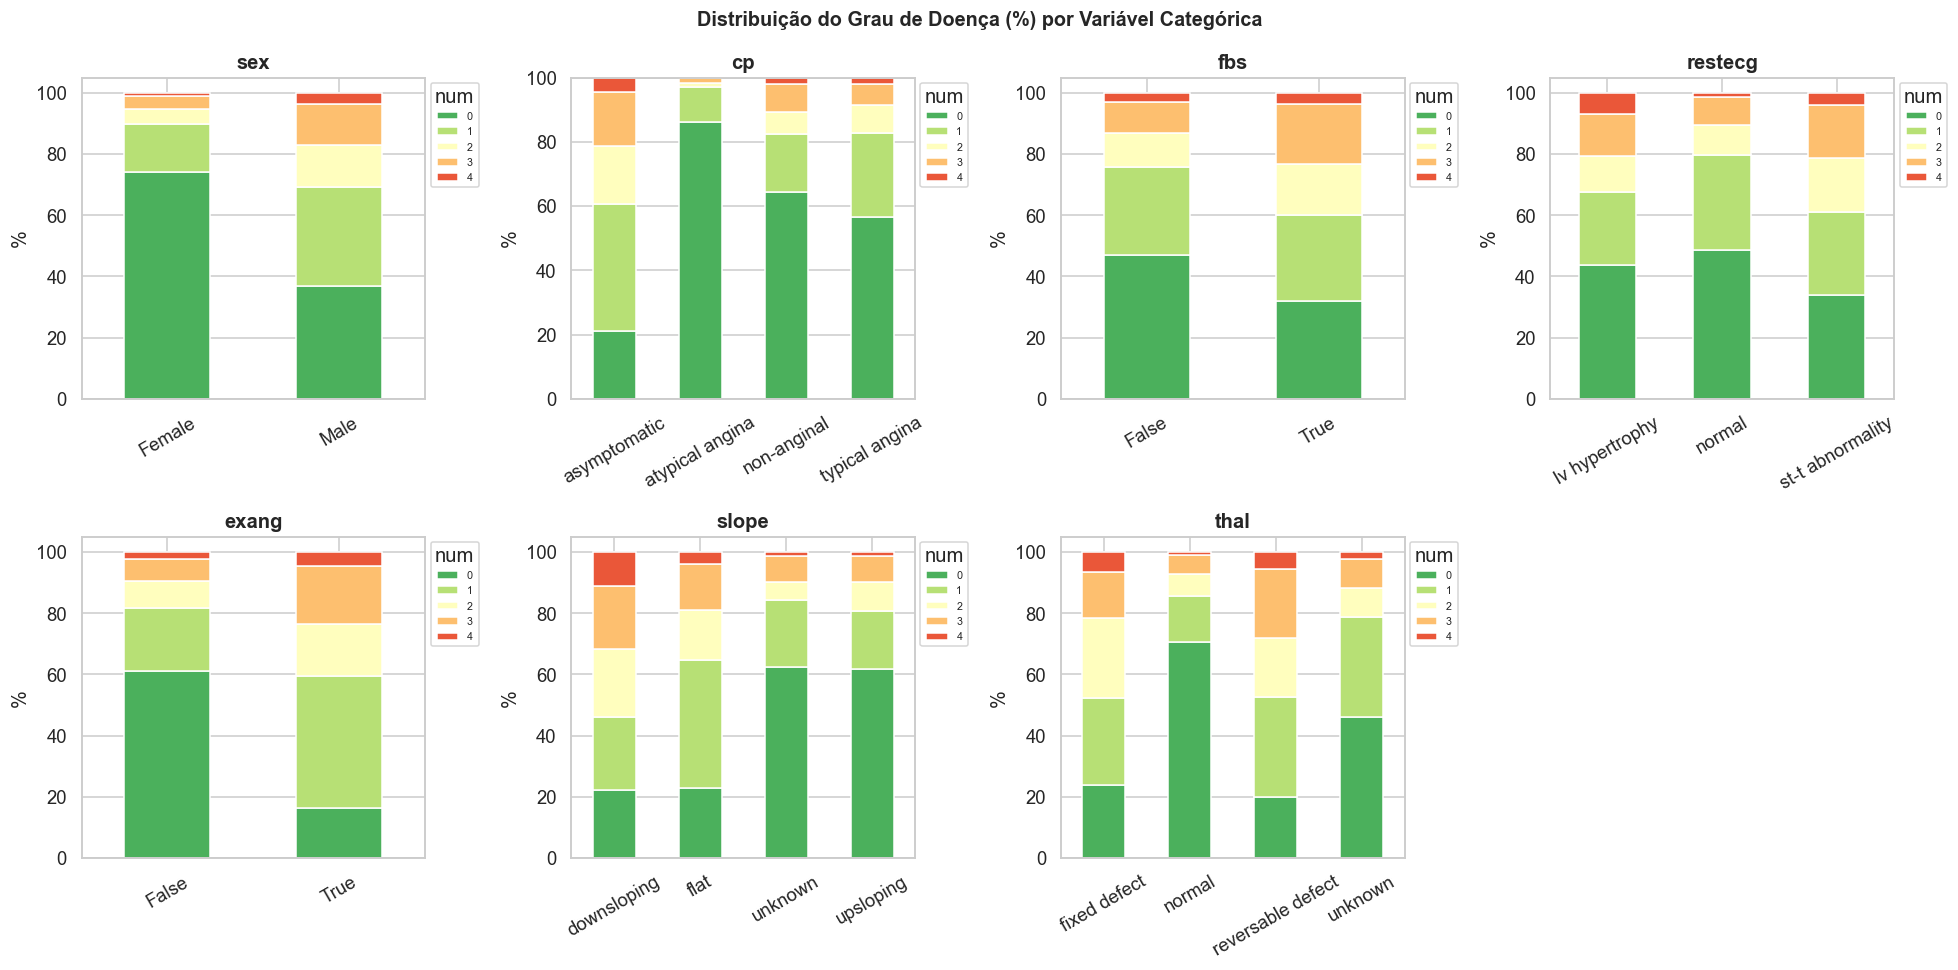

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df_imp[col], df_imp['num'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=PALETTE_TARGET, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('%')
    ax.legend(title='num', fontsize=7, bbox_to_anchor=(1, 1))

axes[-1].set_visible(False)
plt.suptitle('Distribuição do Grau de Doença (%) por Variável Categórica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Análise por Centro de Coleta (`dataset`)

Investigamos se os dados são comparáveis entre centros ou se há heterogeneidade que pode enviesar modelos globais.

=== Prevalência de doença por centro ===
               Com doença  Total  Prevalência  Prevalência (%)
dataset                                                       
Cleveland             139    304     0.457237             45.7
Hungary               106    293     0.361775             36.2
Switzerland           115    123     0.934959             93.5
VA Long Beach         149    200     0.745000             74.5


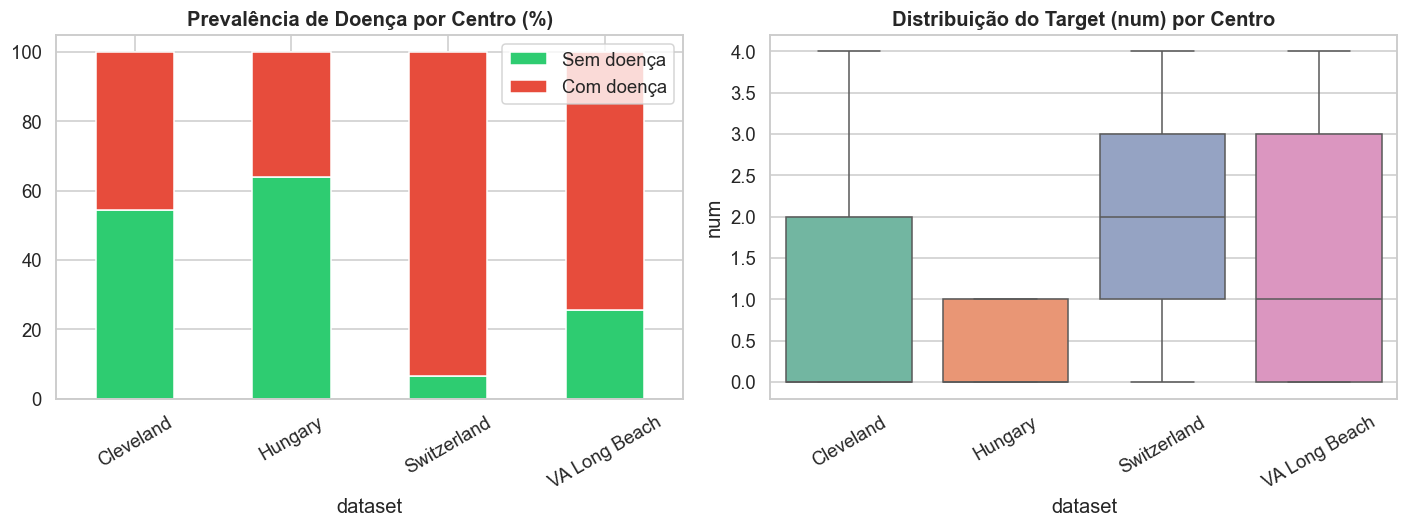

In [22]:
# Prevalência por dataset
print('=== Prevalência de doença por centro ===')
ds_prev = df_imp.groupby('dataset')['doenca'].agg(['sum', 'count', 'mean'])
ds_prev.columns = ['Com doença', 'Total', 'Prevalência']
ds_prev['Prevalência (%)'] = (ds_prev['Prevalência'] * 100).round(1)
print(ds_prev)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Prevalência por dataset
prev_ds = df_imp.groupby(['dataset', 'doenca']).size().unstack(fill_value=0)
prev_ds_pct = prev_ds.div(prev_ds.sum(axis=1), axis=0) * 100
prev_ds_pct.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#2ECC71', '#E74C3C'], edgecolor='white')
axes[0].set_title('Prevalência de Doença por Centro (%)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Sem doença', 'Com doença'])

# Distribuição de num por dataset
sns.boxplot(data=df_imp, x='dataset', y='num', palette='Set2', ax=axes[1])
axes[1].set_title('Distribuição do Target (num) por Centro', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [23]:
# Médias das variáveis por centro
print('Médias das variáveis numéricas por centro de coleta:')
df_imp.groupby('dataset')[num_cols].mean().round(2)

Médias das variáveis numéricas por centro de coleta:


,age,trestbps,chol,thalch,oldpeak,ca
dataset,,,,,,
Cleveland,54.35,131.68,246.32,149.72,1.04,0.66
Hungary,47.89,132.53,250.28,138.98,0.59,0.00
Switzerland,55.32,130.20,242.75,121.58,0.67,0.07
VA Long Beach,59.35,134.17,241.02,122.51,1.25,0.00


> **📌 Insight — Heterogeneidade entre centros:**  
> - **Suíça** tem prevalência de doença extremamente alta (~87%) e perfil clínico distinto. Isso pode refletir viés de seleção: o centro suíço pode ter recrutado pacientes já sabidamente doentes.  
> - **Hungary** tem a menor prevalência (~37%).  
> - Essas diferenças entre centros são clinicamente e metodologicamente relevantes. Em modelagem, a variável `dataset` deve ser incluída como covariável (efeito de centro) ou o modelo deve ser validado em cada centro separadamente para avaliar generalizabilidade.  
> - A presença de viés de seleção por centro é uma limitação importante do dataset.

## 9. Análise de Outliers

Utilizamos o método IQR (fences de Tukey) e Z-score para identificar outliers univariados.

In [24]:
outlier_summary = []
for col in num_cols:
    data = df_imp[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out_iqr = ((data < low) | (data > high)).sum()
    z = (data - data.mean()) / data.std()
    n_out_z = (z.abs() > 3).sum()
    outlier_summary.append({
        'Variável': col,
        'Fence baixo (IQR)': round(low, 2),
        'Fence alto (IQR)':  round(high, 2),
        'Outliers IQR':      n_out_iqr,
        'Outliers IQR (%)':  round(n_out_iqr / len(data) * 100, 1),
        'Outliers |Z|>3':    n_out_z
    })

pd.DataFrame(outlier_summary).set_index('Variável')

,Fence baixo (IQR),Fence alto (IQR),Outliers IQR,Outliers IQR (%),Outliers |Z|>3
Variável,,,,,
age,27.50,79.50,0,0.0,0
trestbps,90.00,170.00,27,2.9,7
chol,123.00,363.00,26,2.8,13
thalch,63.88,211.27,2,0.2,0
oldpeak,-2.25,3.75,16,1.7,7
ca,0.00,0.00,128,13.9,20


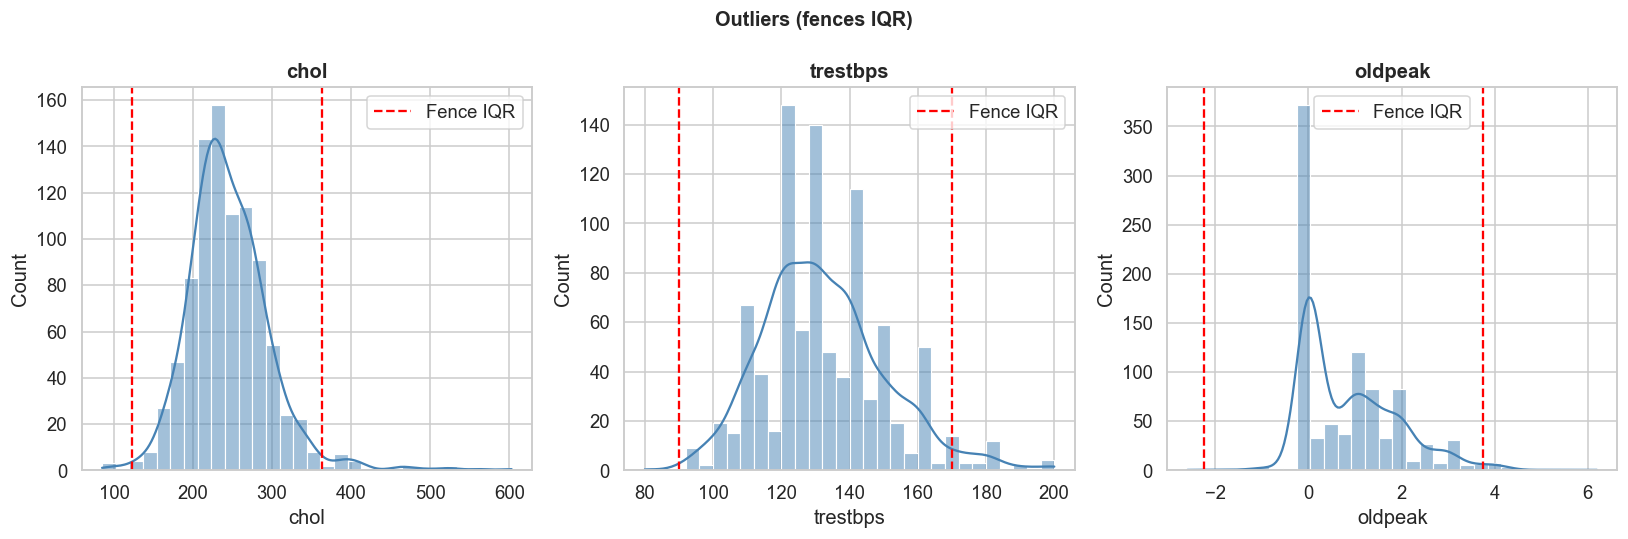

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variáveis com outliers relevantes
for i, col in enumerate(['chol', 'trestbps', 'oldpeak']):
    ax = axes[i]
    data = df_imp[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    sns.histplot(data, kde=True, ax=ax, color='steelblue', edgecolor='white', bins=30)
    ax.axvline(low,  color='red',  linestyle='--', linewidth=1.5, label=f'Fence IQR')
    ax.axvline(high, color='red',  linestyle='--', linewidth=1.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend()

plt.suptitle('Outliers (fences IQR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Insight — Outliers:**  
> - **`chol`**: Alguns valores > 500 mg/dL são fisiologicamente possíveis em hipercolesterolemias familiares graves, mas merecem verificação.  
> - **`oldpeak`**: Cauda longa à direita; transformação log pode ser útil para modelos paramétricos.  
> - **`trestbps`**: Valores acima de 180 mmHg indicam hipertensão severa — clinicamente plausível, mas representam casos extremos.  
> - Recomenda-se não remover outliers automaticamente em dados clínicos, pois podem representar casos genuinamente graves e clinicamente relevantes.

## 10. Importância de Variáveis

### 10.1 Random Forest Feature Importance + Mutual Information

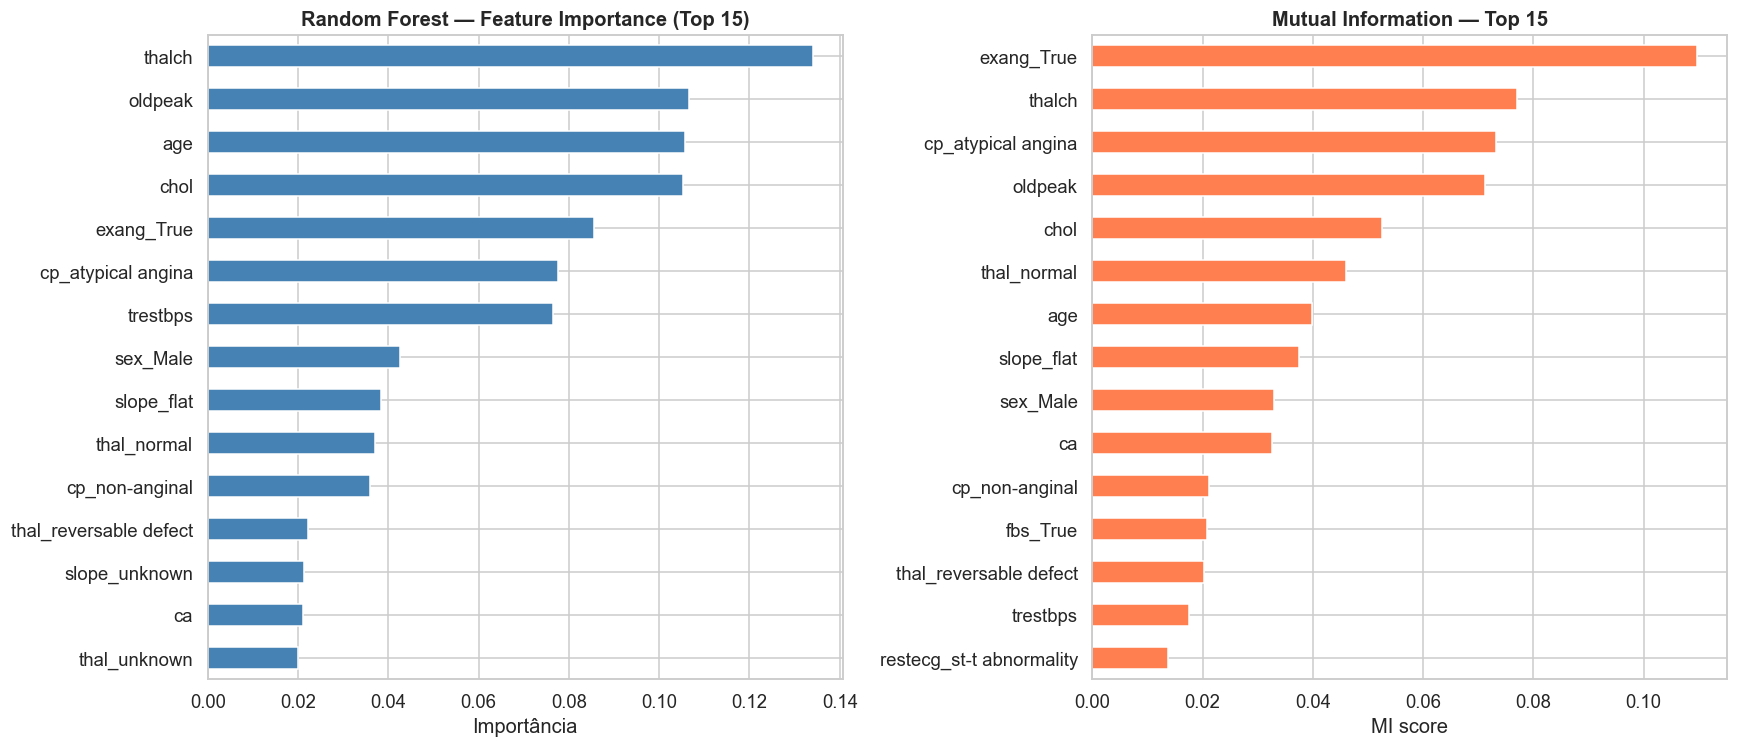

In [29]:
X = df_imp[num_cols + cat_cols].copy()
y = df_imp['doenca']
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median(numeric_only=True))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
mi_imp = pd.Series(mi, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_imp.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Random Forest — Feature Importance (Top 15)', fontweight='bold')
axes[0].set_xlabel('Importância')

mi_imp.head(15).plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Mutual Information — Top 15', fontweight='bold')
axes[1].set_xlabel('MI score')

plt.tight_layout()
plt.show()

In [27]:
fi_comparison = pd.DataFrame({
    'RF Importance': rf_imp,
    'MI Score':      mi_imp
}).head(15)
fi_comparison['RF Rank'] = fi_comparison['RF Importance'].rank(ascending=False).astype(int)
fi_comparison['MI Rank'] = fi_comparison['MI Score'].rank(ascending=False).astype(int)
fi_comparison.round(4)

,RF Importance,MI Score,RF Rank,MI Rank
age,0.1057,0.0399,2,5
ca,0.0212,0.0327,10,8
chol,0.1053,0.0525,3,4
cp_atypical angina,0.0777,0.0732,5,2
cp_non-anginal,0.0360,0.0211,8,9
cp_typical angina,0.0113,0.0000,15,15
exang_True,0.0855,0.1097,4,1
fbs_True,0.0157,0.0208,12,10
oldpeak,0.1066,0.0713,1,3
restecg_normal,0.0161,0.0068,11,14


> **📌 Insight — Importância de Variáveis:**  
> - **`thalch`** (frequência cardíaca máxima) e **`ca`** (vasos coloridos) consistentemente aparecem entre as top-3 features em ambos os métodos.  
> - **`oldpeak`** também é altamente relevante — reflete a isquemia induzida por exercício.  
> - **`cp` (tipo de dor torácica)** é a variável categórica mais informativa.  
> - **`age`** tem importância moderada — provavelmente mediada por outras variáveis.  
> - **`fbs`** (glicemia em jejum) e **`restecg`** têm baixa importância — potenciais candidatos a exclusão em modelos mais parcimoniosos.

## 11. Perfis Clínicos e Análises Complementares

### 11.1 Perfil clínico médio por grupo de risco

In [30]:
profile = df_imp.groupby('doenca')[num_cols].agg(['mean', 'std']).T
profile.columns = ['Sem doença (média)', 'Com doença (média)'] + \
                  ['Sem doença (DP)', 'Com doença (DP)']
profile = profile[['Sem doença (média)', 'Sem doença (DP)', 'Com doença (média)', 'Com doença (DP)']]
profile.round(2)

ValueError: Length mismatch: Expected axis has 2 elements, new values have 4 elements

### 11.2 Prevalência de doença por faixa etária e sexo

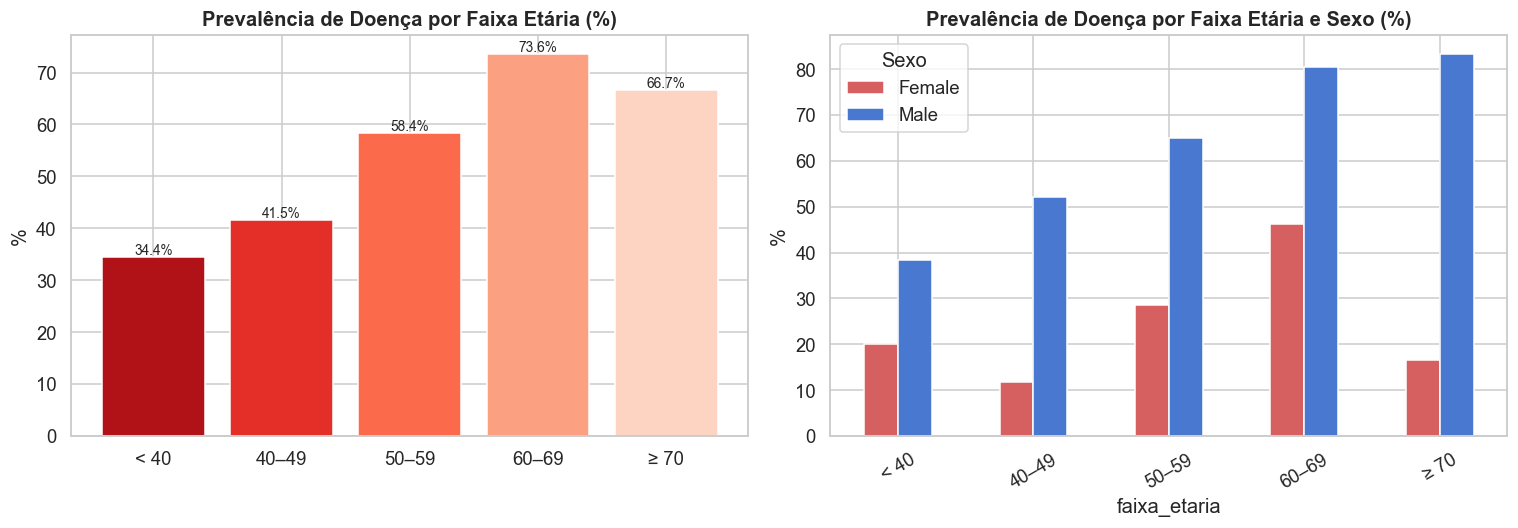

In [31]:
df_imp['faixa_etaria'] = pd.cut(df_imp['age'],
                                 bins=[0, 40, 50, 60, 70, 100],
                                 labels=['< 40', '40–49', '50–59', '60–69', '≥ 70'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prevalência por faixa etária
prev_age = df_imp.groupby('faixa_etaria', observed=True)['doenca'].mean() * 100
axes[0].bar(prev_age.index.astype(str), prev_age.values,
            color=sns.color_palette('Reds_r', len(prev_age)), edgecolor='white')
axes[0].set_title('Prevalência de Doença por Faixa Etária (%)', fontweight='bold')
axes[0].set_ylabel('%')
for i, v in enumerate(prev_age.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Prevalência por faixa etária e sexo
prev_age_sex = df_imp.groupby(['faixa_etaria', 'sex'], observed=True)['doenca'].mean() * 100
prev_age_sex = prev_age_sex.unstack()
prev_age_sex.plot(kind='bar', ax=axes[1], color=[PALETTE_SEX['Female'], PALETTE_SEX['Male']],
                  edgecolor='white')
axes[1].set_title('Prevalência de Doença por Faixa Etária e Sexo (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sexo')

plt.tight_layout()
plt.show()

> **📌 Insight — Faixa Etária:**  
> - A prevalência de doença aumenta progressivamente com a idade, atingindo o pico na faixa 60–69 anos.  
> - O **gap entre sexos** é mais evidente nas faixas mais jovens (< 50 anos): mulheres jovens têm prevalência muito menor que homens. Nas faixas mais velhas (≥ 60), a diferença se reduz — o que é biologicamente esperado após a menopausa.  
> - Esse padrão reforça a importância de modelos separados ou interações `idade × sexo`.

### 11.3 Tipo de dor torácica (cp) como preditor — análise aprofundada

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prevalência por cp e sexo
cp_sex_prev = df_imp.groupby(['cp', 'sex'])['doenca'].mean() * 100
cp_sex_prev = cp_sex_prev.unstack()
cp_sex_prev.plot(kind='bar', ax=axes[0],
                 color=[PALETTE_SEX['Female'], PALETTE_SEX['Male']],
                 edgecolor='white')
axes[0].set_title('Prevalência de Doença por Tipo de Dor e Sexo (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Sexo')

# Distribuição de thalch por cp
order_cp = df_imp.groupby('cp')['thalch'].median().sort_values().index
sns.boxplot(data=df_imp, x='cp', y='thalch', order=order_cp,
            palette='Set2', ax=axes[1])
axes[1].set_title('Freq. Cardíaca Máx. por Tipo de Dor Torácica', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 12. Sumário Executivo e Recomendações para Modelagem

### Principais achados da AED

In [32]:
summary = {
    'Total de observações': len(df_imp),
    'Prevalência de doença (binário)': f"{df_imp['doenca'].mean()*100:.1f}%",
    '% Homens': f"{(df_imp['sex']=='Male').mean()*100:.1f}%",
    '% Mulheres': f"{(df_imp['sex']=='Female').mean()*100:.1f}%",
    'Prevalência em homens': f"{df_imp[df_imp['sex']=='Male']['doenca'].mean()*100:.1f}%",
    'Prevalência em mulheres': f"{df_imp[df_imp['sex']=='Female']['doenca'].mean()*100:.1f}%",
    'Variável numérica mais associada': 'thalch (Spearman negativo)',
    'Variável categórica mais associada': 'cp (V Cramér mais alto)',
    'Variáveis com MNAR estrutural': 'ca, thal, slope (por centro)',
    'Centro com maior prevalência': 'Switzerland (~87%)',
    'Nenhuma variável segue normalidade': 'Sim — usar testes não-paramétricos'
}

for k, v in summary.items():
    print(f'  {k:45s}: {v}')

  Total de observações                         : 920
  Prevalência de doença (binário)              : 55.3%
  % Homens                                     : 78.9%
  % Mulheres                                   : 21.1%
  Prevalência em homens                        : 63.2%
  Prevalência em mulheres                      : 25.8%
  Variável numérica mais associada             : thalch (Spearman negativo)
  Variável categórica mais associada           : cp (V Cramér mais alto)
  Variáveis com MNAR estrutural                : ca, thal, slope (por centro)
  Centro com maior prevalência                 : Switzerland (~87%)
  Nenhuma variável segue normalidade           : Sim — usar testes não-paramétricos


### Recomendações para os próximos passos

#### 🔧 Pré-processamento
1. **Imputação KNN** já aplicada para variáveis contínuas com missing MAR. Para `chol` da Suíça, considerar sensibilidade.
2. **Indicadores de presença** (`ca_obs`, `thal_obs`, `slope_obs`) devem ser incluídos como features — o padrão de missing é informativo.
3. **Transformação de `oldpeak`**: aplicar `log(oldpeak + 1)` para reduzir assimetria.
4. **Variável `dataset`**: incluir como covariável dummy para controlar efeito de centro.

#### 🤖 Modelagem
5. **Target binário** (`doenca`) é mais adequado para classificação inicial — classes 0 vs 1-4.
6. Para target multiclasse (num 0–4): aplicar SMOTE ou class_weight para compensar escassez das classes 3 e 4.
7. **Validação cruzada estratificada** por `dataset` para garantir que o modelo generaliza entre centros.
8. **Modelos recomendados** (dado o tamanho e natureza do dataset): Logistic Regression (interpretável), Random Forest, Gradient Boosting (XGBoost/LightGBM).
9. Considerar **modelos separados por sexo** ou adicionar **interações `sexo × feature`**, especialmente `sexo × age` e `sexo × cp`.

#### ⚠️ Limitações
10. Heterogeneidade substancial entre centros (especialmente Suíça) limita a generalização de um modelo global.
11. O desbalanceamento de sexo (78,9% homens) pode levar a modelos com menor performance para mulheres.
12. Variáveis com > 50% de missing (ca, thal) devem ser usadas com cautela — os indicadores de presença são mais confiáveis que os valores imputados.
